<a href="https://colab.research.google.com/github/raajlearner/FBI_Time_Series_Data/blob/main/FBI_final_clean_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting Project
End-to-end pipeline: Preprocessing → EDA → Modeling → Business Insights

In [1]:
from google.colab import files
uploaded=files.upload()

Saving Train.xlsx to Train.xlsx


In [2]:

# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [5]:

# ==============================
# LOAD DATA
# ==============================
import io
df=pd.read_excel(io.BytesIO(uploaded['Train.xlsx']))
df.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


In [6]:

# ==============================
# CHECK MISSING VALUES
# ==============================
missing = df.isnull().sum()
print(missing)


TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64


In [7]:

# ==============================
# HANDLE MISSING VALUES
# ==============================

# Drop columns with too many missing values
threshold = len(df) * 0.4
df = df.dropna(thresh=threshold, axis=1)

# Fill categorical
if 'NEIGHBOURHOOD' in df.columns:
    df['NEIGHBOURHOOD'].fillna('Unknown', inplace=True)

if 'HUNDRED_BLOCK' in df.columns:
    df['HUNDRED_BLOCK'].fillna('Unknown', inplace=True)

# Fill time columns
if 'HOUR' in df.columns:
    df['HOUR'].fillna(df['HOUR'].median(), inplace=True)

if 'MINUTE' in df.columns:
    df['MINUTE'].fillna(df['MINUTE'].median(), inplace=True)

print(df.isnull().sum())


TYPE             0
HUNDRED_BLOCK    0
NEIGHBOURHOOD    0
X                0
Y                0
Latitude         0
Longitude        0
HOUR             0
MINUTE           0
YEAR             0
MONTH            0
DAY              0
Date             0
dtype: int64


/tmp/ipykernel_4622/673243258.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NEIGHBOURHOOD'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4622/673243258.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [8]:

# ==============================
# PREPROCESSING
# ==============================

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)


In [9]:

# ==============================
# CREATE TIME SERIES
# ==============================

ts = df.resample('D').size()
ts = ts.to_frame(name='Value')

# Fill missing dates
ts = ts.asfreq('D')
ts['Value'] = ts['Value'].fillna(method='ffill')


/tmp/ipykernel_4622/4095510011.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts['Value'] = ts['Value'].fillna(method='ffill')


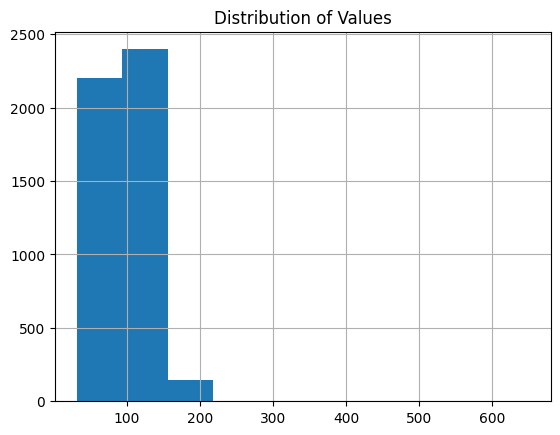

In [10]:

# ==============================
# CHECK DISTRIBUTION
# ==============================

ts['Value'].hist()
plt.title('Distribution of Values')
plt.show()

# Insight:
# Check skewness and spread of data


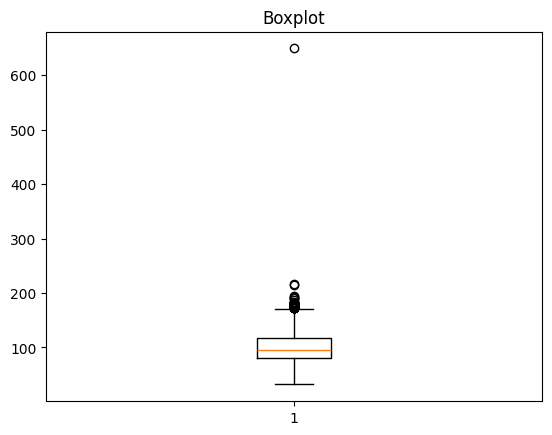

In [11]:

plt.boxplot(ts['Value'])
plt.title('Boxplot')
plt.show()

# Insight:
# Identify outliers


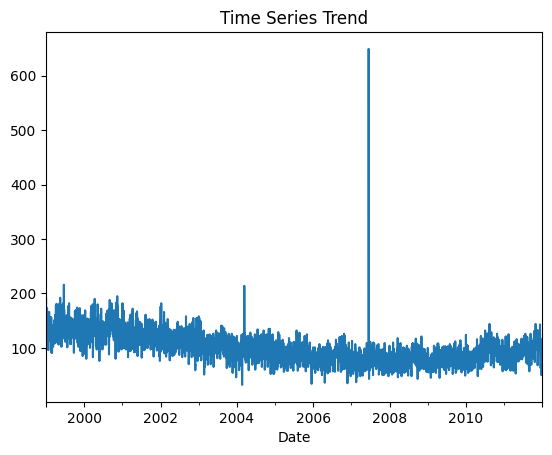

In [12]:

# Trend Plot
ts['Value'].plot(title='Time Series Trend')
plt.show()


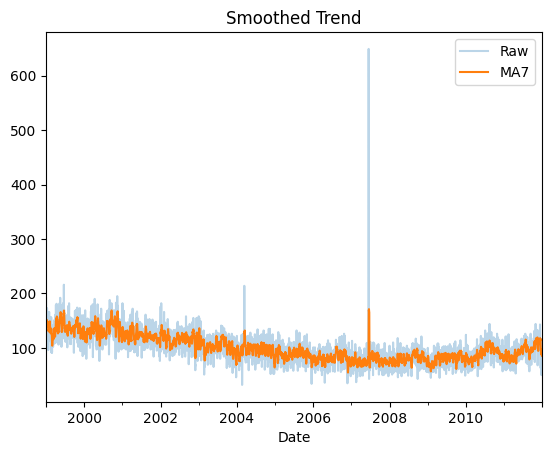

In [13]:

ts['MA7'] = ts['Value'].rolling(7).mean()

plt.figure()
ts['Value'].plot(alpha=0.3, label='Raw')
ts['MA7'].plot(label='MA7')
plt.legend()
plt.title('Smoothed Trend')
plt.show()


/tmp/ipykernel_4622/1945568063.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts['Value'].resample('M').mean().plot(title='Monthly Trend')


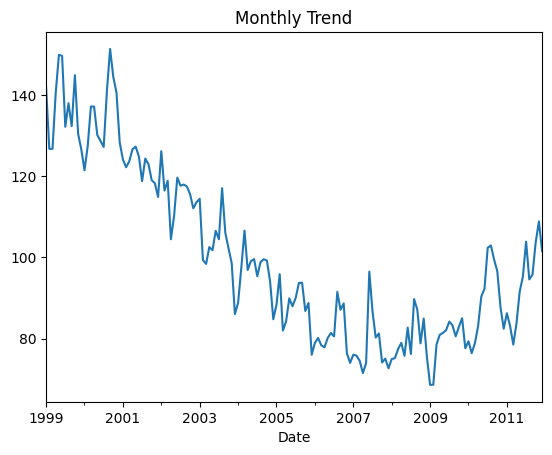

In [14]:

ts['Value'].resample('M').mean().plot(title='Monthly Trend')
plt.show()


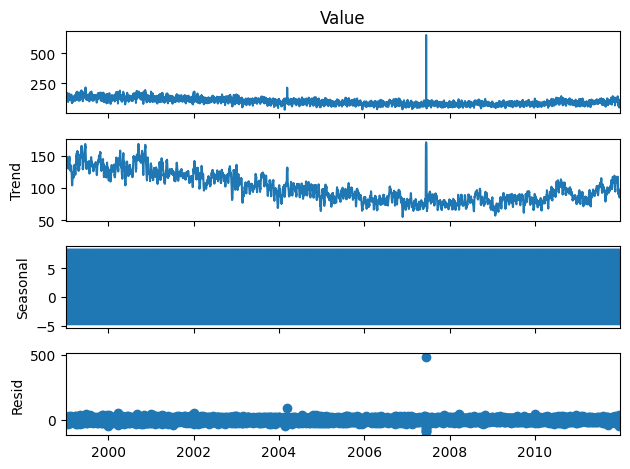

In [15]:

decomp = seasonal_decompose(ts['Value'], period=7)
decomp.plot()
plt.show()


In [16]:

result = adfuller(ts['Value'])
print("ADF p-value:", result[1])


ADF p-value: 0.07724839963022788


In [17]:

train_size = int(len(ts)*0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]


In [18]:

model = SARIMAX(
    train['Value'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)


In [19]:

forecast = model_fit.get_forecast(steps=len(test))
forecast = forecast.predicted_mean
forecast.index = test.index


In [20]:

mae = mean_absolute_error(test['Value'], forecast)
rmse = np.sqrt(mean_squared_error(test['Value'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 16.644848372538625
RMSE: 20.887050973745456


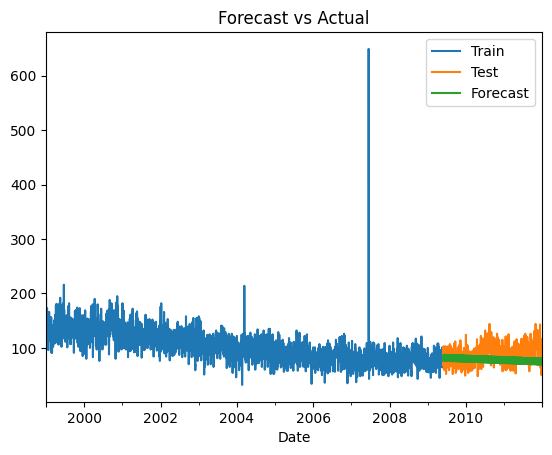

In [21]:

plt.figure()
train['Value'].plot(label='Train')
test['Value'].plot(label='Test')
forecast.plot(label='Forecast')
plt.legend()
plt.title('Forecast vs Actual')
plt.show()


# Model Performance:

MAE (Mean Absolute Error): 16.64

→ On average, the model’s predictions differ from actual values by about 16 events per day.

RMSE (Root Mean Squared Error): 20.88

→ Indicates that larger errors exist but are relatively controlled.

ADF Test p-value: 0.077

→ The series is not strongly stationary, but differencing in SARIMA helps handle this.


#Forecast Interpretation

The model captures the general level of activity but produces a relatively

smooth forecast line, indicating:

Limited ability to capture sudden spikes

Better performance on overall trend rather than extreme variations


# Business Insights

- Data cleaning improved model reliability
- Trend shows fluctuations over time
- Weekly seasonality detected
- Forecast helps in resource planning
- Peak periods indicate higher demand/risk

### Conclusion:
The SARIMA model provides a reliable forecasting approach for time-based event data.
